# Libs

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Plot Style

In [2]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e5e5e0",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#52514e",
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLOR_EXISTING = "#2a78d6"  # categorical slot 1 (blue)
COLOR_NEW = "#eb6834"  # categorical slot 2 (orange)
COLOR_NEUTRAL = "#8a8a85"  # muted reference lines
SEQUENTIAL_BLUES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]

# Helpers

In [3]:
def apply_episode_cooldown(active_grid, cooldown_days):
    """Select one training snapshot per eligibility episode.

    Starting from a customer's first active snapshot date, the next
    training snapshot is the first later active date at least
    cooldown_days after it, and so on. This removes near-duplicate,
    overlapping snapshots from the training population. (Reused
    unchanged from notebooks/06_data_understanding.ipynb and
    notebooks/07_data_preparation.ipynb.)

    Args:
        active_grid: Active rows with customer_id and
            snapshot_date columns.
        cooldown_days: Minimum gap in days between two training
            snapshots of the same customer (C).

    Returns:
        The subset of active_grid rows selected as training
        snapshots.
    """
    cooldown = pd.Timedelta(days=cooldown_days)
    ordered = active_grid.sort_values(["customer_id", "snapshot_date"])
    selected_index = []
    for _, rows in ordered.groupby("customer_id"):
        next_allowed = None
        for row in rows.itertuples():
            allowed = next_allowed is None or row.snapshot_date >= (
                next_allowed
            )
            if allowed:
                selected_index.append(row.Index)
                next_allowed = row.snapshot_date + cooldown
    return active_grid.loc[selected_index]

In [4]:
def precision_at_k(y_true, scores, k_frac):
    """Precision within the top k_frac of ranked scores.

    Args:
        y_true: Array-like of 0/1 true churn labels.
        scores: Array-like of churn-risk scores, aligned with
            y_true (higher = more likely to churn).
        k_frac: Fraction of rows treated as "targeted" (e.g. 0.1
            for the top 10%).

    Returns:
        The churn rate among the top k_frac of rows by score.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(int(round(len(scores) * k_frac)), 1)
    top_idx = np.argsort(-scores)[:k]
    return y_true[top_idx].mean()


def lift_at_k(y_true, scores, k_frac):
    """Lift of the top k_frac segment over the overall base rate."""
    y_true = np.asarray(y_true)
    base_rate = y_true.mean()
    return precision_at_k(y_true, scores, k_frac) / base_rate


def gain_at_k(y_true, scores, k_frac):
    """Share of all positives captured within the top k_frac."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(int(round(len(scores) * k_frac)), 1)
    top_idx = np.argsort(-scores)[:k]
    return y_true[top_idx].sum() / y_true.sum()


def evaluate_ranking(y_true, scores, k_frac=0.10):
    """Pooled predictive + ranking metrics at one operating point.

    Metrics are pooled across all rows passed in, not computed per
    scoring week and averaged -- that per-week treatment is left to
    Chapter 9. This is enough to select between candidate models.

    Args:
        y_true: Array-like of 0/1 true churn labels.
        scores: Array-like of churn-risk scores.
        k_frac: Operating top-K fraction for ranking metrics.

    Returns:
        A dict with roc_auc, pr_auc, precision_at_k, lift_at_k,
        gain_at_k.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    pct = int(k_frac * 100)
    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        f"precision_at_{pct}": precision_at_k(y_true, scores, k_frac),
        f"lift_at_{pct}": lift_at_k(y_true, scores, k_frac),
        f"gain_at_{pct}": gain_at_k(y_true, scores, k_frac),
    }

In [5]:
LOG_FEATURES = [
    "monetary_so_far", "avg_order_value_so_far", "tenure_days",
    "mean_gap_so_far", "recency_to_typical_gap", "activity_last_90d",
    "distinct_products_so_far", "cancel_count_so_far",
    "frequency_so_far",
]


def prepare_features(df, features):
    """Select feature columns, log1p-transforming the skewed ones.

    Several engineered features (revenue, counts, ratios) are
    extremely right-skewed (Section 8.9 and Section 7.6's known
    instability note) -- even after standard scaling, a single
    extreme outlier can still overflow Logistic Regression's linear
    predictor. log1p is deterministic (no fitted parameters), so
    applying it introduces no leakage.

    Args:
        df: DataFrame containing `features`.
        features: List of feature column names to select.

    Returns:
        A new DataFrame with the same columns, skewed ones log1p-
        transformed.
    """
    X = df[features].copy()
    for col in features:
        if col in LOG_FEATURES:
            X[col] = np.log1p(X[col])
    return X


def fit_and_score(model, features, train_df, eval_df,
                   sample_weight=None):
    """Fit a median-imputed, standardized model and score eval_df.

    The imputer and scaler are fit on train_df only (Section
    7.8/8.7 leakage rule: aggregates that depend on the data are
    fitted on the training period only). Scaling (after log1p-
    transforming the most skewed features in prepare_features)
    matters most for Logistic Regression -- feature magnitudes here
    range from single digits (recency_days) to the hundreds of
    thousands (monetary_so_far); it is harmless for the
    scale-invariant tree models, so it is applied uniformly.

    Args:
        model: An unfitted scikit-learn-compatible classifier.
        features: List of feature column names.
        train_df: Training rows (must have a churn column).
        eval_df: Rows to score (must have a churn column).
        sample_weight: Optional per-row training weights, aligned
            with train_df.

    Returns:
        A tuple (metrics dict from evaluate_ranking, (imputer,
        scaler, fitted model)).
    """
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(prepare_features(train_df, features))
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    y_train = train_df["churn"]
    if sample_weight is None:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)

    X_eval = scaler.transform(
        imputer.transform(prepare_features(eval_df, features))
    )
    scores = model.predict_proba(X_eval)[:, 1]
    metrics = evaluate_ranking(eval_df["churn"], scores)
    return metrics, (imputer, scaler, model)


def build_model(name, params):
    """Construct a fresh, unfitted classifier.

    Args:
        name: One of "logistic_regression", "random_forest",
            "xgboost".
        params: Dict of hyperparameters passed to the constructor.

    Returns:
        An unfitted scikit-learn-compatible classifier.
    """
    if name == "logistic_regression":
        return LogisticRegression(
            max_iter=1000, solver="liblinear", **params
        )
    if name == "random_forest":
        return RandomForestClassifier(
            random_state=0, n_jobs=-1, **params
        )
    if name == "xgboost":
        return XGBClassifier(
            eval_metric="logloss", random_state=0, n_jobs=-1, **params
        )
    raise ValueError(f"Unknown algorithm: {name}")

# Load

In [6]:
modeling_dataset = pd.read_parquet(
    "../data/processed/modeling_dataset_h90.parquet"
)
modeling_dataset.shape

(208764, 20)

**Chosen parameters (inherited from Chapters 6-7).** $H = 90$
days, $R_{\max} = 136$ days (P90), training-episode cooldown
$C = 90$ days.

In [7]:
H = 90
COOLDOWN_DAYS = H

RFM_FEATURES = ["recency_days", "frequency_so_far", "monetary_so_far"]
EXTENDED_FEATURES = RFM_FEATURES + [
    "avg_order_value_so_far", "tenure_days", "mean_gap_so_far",
    "recency_to_typical_gap", "activity_last_90d",
]
FULL_FEATURES = EXTENDED_FEATURES + [
    "distinct_products_so_far", "cancel_count_so_far",
    "cancel_value_share_so_far",
]

## 8.1 Modeling Objective

Estimate $P(\text{Churn} = 1 \mid \text{Customer History at
Snapshot})$ on `data/processed/modeling_dataset_h90.parquet`
(Chapter 7's output). Per the Section 7.9 split table: **Train**
is `in_training_sample` rows within `split=="train"` (the
episode-sampled scheme, used as the default training population
throughout this chapter); **Validation** and **Test** are every row
in their respective split (`in_scoring_population` is always true
in this table, since it already contains active rows only).

In [8]:
train_df = modeling_dataset[
    (modeling_dataset["split"] == "train")
    & modeling_dataset["in_training_sample"]
]
val_df = modeling_dataset[modeling_dataset["split"] == "validation"]
test_df = modeling_dataset[modeling_dataset["split"] == "test"]

print(f"Train (episode-sampled): {len(train_df):,} rows")
print(f"Validation: {len(val_df):,} rows")
print(f"Test: {len(test_df):,} rows")
print(f"Train churn rate: {train_df['churn'].mean():.1%}")
print(f"Validation churn rate: {val_df['churn'].mean():.1%}")

Train (episode-sampled): 6,453 rows
Validation: 21,514 rows
Test: 24,252 rows
Train churn rate: 46.7%
Validation churn rate: 52.9%


## 8.2 Baselines

**Random ranking**: uniform random scores (no learning).
**Recency rule**: score = recency in days (longer since last
purchase ranks higher risk), with no learned parameters. Both are
evaluated on validation at the same operating point ($K=10\%$) as
every model in this chapter.

In [9]:
rng = np.random.default_rng(0)
random_scores = rng.uniform(size=len(val_df))
recency_scores = val_df["recency_days"].to_numpy()

baseline_results = pd.DataFrame({
    "random": evaluate_ranking(val_df["churn"], random_scores),
    "recency_rule": evaluate_ranking(val_df["churn"], recency_scores),
}).T
baseline_results.round(3)

,roc_auc,pr_auc,precision_at_10,lift_at_10,gain_at_10
random,0.495,0.527,0.535,1.012,0.101
recency_rule,0.673,0.673,0.731,1.382,0.138


## 8.3 RFM Model

Logistic Regression on the 3 RFM features only. No missing values
in this feature set, so no imputation is needed.

In [10]:
rfm_metrics, _ = fit_and_score(
    LogisticRegression(max_iter=1000, solver="liblinear"),
    RFM_FEATURES, train_df, val_df
)
pd.Series(rfm_metrics).round(3)

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


roc_auc            0.770
pr_auc             0.748
precision_at_10    0.801
lift_at_10         1.516
gain_at_10         0.152
dtype: float64

## 8.4 Extended Feature Model

Add purchase-behavior and temporal features. `mean_gap_so_far` and
`recency_to_typical_gap` are `NaN` for customers with only one
occasion so far -- `fit_and_score`'s median imputer (fit on train
only) handles this.

In [11]:
extended_metrics, _ = fit_and_score(
    LogisticRegression(max_iter=1000, solver="liblinear"),
    EXTENDED_FEATURES, train_df, val_df,
)
pd.Series(extended_metrics).round(3)

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


roc_auc            0.766
pr_auc             0.743
precision_at_10    0.794
lift_at_10         1.502
gain_at_10         0.150
dtype: float64

## 8.5 Full Feature Model

Add product- and cancellation-behavior features.

In [12]:
full_metrics, _ = fit_and_score(
    LogisticRegression(max_iter=1000, solver="liblinear"),
    FULL_FEATURES, train_df, val_df
)

feature_progression = pd.DataFrame({
    "RFM": rfm_metrics,
    "Extended": extended_metrics,
    "Full": full_metrics,
}).T
feature_progression.round(3)

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,roc_auc,pr_auc,precision_at_10,lift_at_10,gain_at_10
RFM,0.770,0.748,0.801,1.516,0.152
Extended,0.766,0.743,0.794,1.502,0.150
Full,0.766,0.744,0.789,1.492,0.149


## 8.6 Algorithms

Compare Logistic Regression, Random Forest and XGBoost on the Full
feature set, with reasonable default hyperparameters, all trained
on the same episode-sampled train rows and scored on validation.

In [13]:
default_models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000, solver="liblinear"
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=0, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        eval_metric="logloss", random_state=0, n_jobs=-1,
    ),
}

algorithm_results = {}
for name, model in default_models.items():
    metrics, _ = fit_and_score(model, FULL_FEATURES, train_df, val_df)
    algorithm_results[name] = metrics

algorithm_comparison = pd.DataFrame(algorithm_results).T
algorithm_comparison.round(3)

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,roc_auc,pr_auc,precision_at_10,lift_at_10,gain_at_10
logistic_regression,0.766,0.744,0.789,1.492,0.149
random_forest,0.763,0.736,0.786,1.487,0.149
xgboost,0.714,0.697,0.762,1.441,0.144


In [14]:
best_algorithm = algorithm_comparison["pr_auc"].idxmax()
print(f"Best algorithm by validation PR-AUC: {best_algorithm}")

Best algorithm by validation PR-AUC: logistic_regression


## 8.7 Hyperparameter Tuning

Tune a small grid for the winning algorithm on the validation
period (fit on train, select by validation PR-AUC) -- not a
cross-validated search, to preserve the temporal/episode structure.
After selection, retrain on the Training Population **re-derived
over train + validation** (the episode-cooldown rule is re-applied
to this longer window, not just the union of the two periods'
original flags) and evaluate once on test.

In [15]:
PARAM_GRIDS = {
    "logistic_regression": [{"C": c} for c in [0.01, 0.1, 1.0, 10.0]],
    "random_forest": [
        {"n_estimators": n, "max_depth": d}
        for n in [200, 400]
        for d in [6, 10]
    ],
    "xgboost": [
        {"n_estimators": n, "max_depth": d, "learning_rate": lr}
        for n in [200, 400]
        for d in [3, 5]
        for lr in [0.05, 0.1]
    ],
}

tuning_rows = []
for params in PARAM_GRIDS[best_algorithm]:
    model = build_model(best_algorithm, params)
    metrics, _ = fit_and_score(model, FULL_FEATURES, train_df, val_df)
    tuning_rows.append({"params": str(params), **metrics})

tuning_results = pd.DataFrame(tuning_rows)
best_idx = tuning_results["pr_auc"].idxmax()
best_params = PARAM_GRIDS[best_algorithm][best_idx]
print(f"Best hyperparameters: {best_params}")
tuning_results.round(3)

Best hyperparameters: {'C': 0.01}


/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/si

,params,roc_auc,pr_auc,precision_at_10,lift_at_10,gain_at_10
0,{'C': 0.01},0.770,0.748,0.791,1.496,0.150
1,{'C': 0.1},0.767,0.745,0.784,1.484,0.148
2,{'C': 1.0},0.766,0.744,0.789,1.492,0.149
3,{'C': 10.0},0.766,0.744,0.790,1.495,0.149


In [16]:
train_start = train_df["snapshot_date"].min()
val_end = val_df["snapshot_date"].max()

refit_pool = modeling_dataset[
    (modeling_dataset["snapshot_date"] >= train_start)
    & (modeling_dataset["snapshot_date"] <= val_end)
    & modeling_dataset["labelable"]
]
refit_training_rows = apply_episode_cooldown(
    refit_pool[["customer_id", "snapshot_date"]],
    cooldown_days=COOLDOWN_DAYS,
)
refit_train_df = refit_pool.loc[refit_training_rows.index]
print(
    f"Final-refit training rows (train+validation, re-derived): "
    f"{len(refit_train_df):,}"
)

final_metrics, (final_imputer, final_scaler, final_model) = fit_and_score(
    build_model(best_algorithm, best_params), FULL_FEATURES,
    refit_train_df, test_df,
)
print(f"Final model: {best_algorithm} {best_params}")
pd.Series(final_metrics).round(3)

Final-refit training rows (train+validation, re-derived): 12,019
Final model: logistic_regression {'C': 0.01}


/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


roc_auc            0.764
pr_auc             0.659
precision_at_10    0.773
lift_at_10         1.929
gain_at_10         0.193
dtype: float64

## 8.8 Model Selection

_Filled in after reviewing the real results above: which algorithm
won in 8.6, the tuned hyperparameters from 8.7, and how the Full
feature set's validation performance compares to RFM/Extended from
8.3-8.5 and to the baselines from 8.2 -- with particular attention
to Lift@10%/Precision@10% at the operating $K$, not just ROC-AUC._

## 8.9 Model Interpretability

SHAP values for the final refit model, computed on a sample of up
to 1,000 test rows (`TreeExplainer` for Random Forest/XGBoost,
`LinearExplainer` for Logistic Regression). Findings below describe
associations the model has learned, not causal effects (Section
3.14).

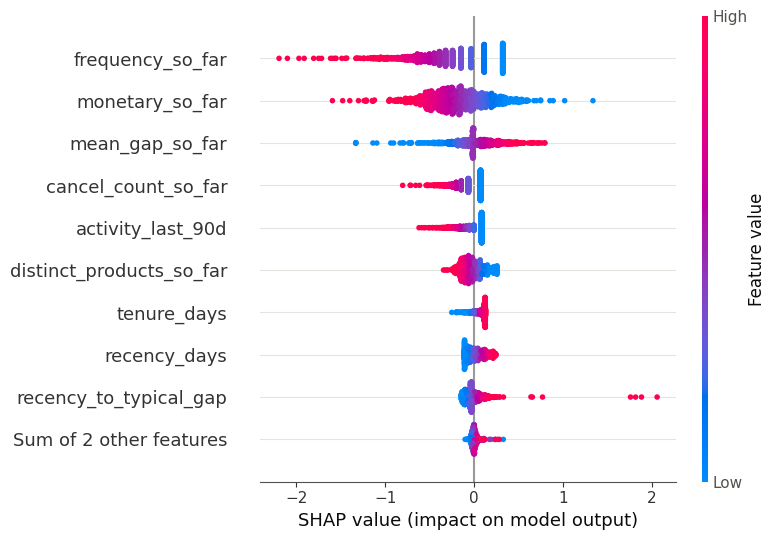

In [17]:
sample_test = test_df.sample(n=min(1000, len(test_df)), random_state=0)
X_sample = pd.DataFrame(
    final_scaler.transform(
        final_imputer.transform(
            prepare_features(sample_test, FULL_FEATURES)
        )
    ),
    columns=FULL_FEATURES,
)

if best_algorithm == "logistic_regression":
    background_sample = refit_train_df.sample(
        n=min(200, len(refit_train_df)), random_state=0
    )
    background = final_scaler.transform(final_imputer.transform(
        prepare_features(background_sample, FULL_FEATURES)
    ))
    explainer = shap.LinearExplainer(
        final_model, background, feature_names=FULL_FEATURES
    )
else:
    explainer = shap.TreeExplainer(final_model)

shap_values = explainer(X_sample)
if (
    hasattr(shap_values, "values")
    and np.ndim(shap_values.values) == 3
):
    shap_values = shap_values[..., 1]

shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig(
    "../latex/figures/ch8_shap_summary.png", dpi=150,
    bbox_inches="tight",
)
plt.show()

## 8.10 Training Population Ablation

Compare two training schemes for the selected algorithm, feature
set and hyperparameters, both trained on the **train period only**
(not the extended refit pool from 8.7) and evaluated on the **same
test set**: Scheme A is the episode-sampled rows used throughout
this chapter; Scheme B is every active row in the train period,
weighted by `sample_weight` (Section 7.9).

In [18]:
scheme_a_train = train_df
scheme_b_train = modeling_dataset[modeling_dataset["split"] == "train"]

metrics_a, _ = fit_and_score(
    build_model(best_algorithm, best_params), FULL_FEATURES,
    scheme_a_train, test_df,
)
metrics_b, _ = fit_and_score(
    build_model(best_algorithm, best_params), FULL_FEATURES,
    scheme_b_train, test_df,
    sample_weight=scheme_b_train["sample_weight"],
)

ablation_results = pd.DataFrame({
    "A_episode": metrics_a,
    "B_weighted_all": metrics_b,
}).T
ablation_results.round(3)

/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/si

,roc_auc,pr_auc,precision_at_10,lift_at_10,gain_at_10
A_episode,0.750,0.631,0.716,1.787,0.179
B_weighted_all,0.755,0.649,0.766,1.912,0.191
